In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks", color_codes=True)

# load data
df_ev = pd.read_csv("../tmp/events.csv")
df_ev["timestamp"] = pd.to_datetime(df_ev["timestamp"], unit="ms")
df_ip = pd.concat(
    [
        pd.read_csv("../tmp/item_properties_part1.csv"),
        pd.read_csv("../tmp/item_properties_part2.csv"),
    ],
    ignore_index=True,
)

In [2]:
# formato
print(f"formato {df_ev.shape}")
print(f"linhas {df_ev.shape[0]} | colunas {df_ev.shape[1]}")
print()

# head
print("head")
print(df_ev.head())
print()

# tail
print("tail")
print(df_ev.tail())
print()

# types
print("types")
print(df_ev.dtypes)
print()

# describe df_ev
df_ev.describe()

formato (2756101, 5)
linhas 2756101 | colunas 5

head
                timestamp  visitorid event  itemid  transactionid
0 2015-06-02 05:02:12.117     257597  view  355908            NaN
1 2015-06-02 05:50:14.164     992329  view  248676            NaN
2 2015-06-02 05:13:19.827     111016  view  318965            NaN
3 2015-06-02 05:12:35.914     483717  view  253185            NaN
4 2015-06-02 05:02:17.106     951259  view  367447            NaN

tail
                      timestamp  visitorid event  itemid  transactionid
2756096 2015-08-01 03:13:05.939     591435  view  261427            NaN
2756097 2015-08-01 03:30:13.142     762376  view  115946            NaN
2756098 2015-08-01 02:57:00.527    1251746  view   78144            NaN
2756099 2015-08-01 03:08:50.703    1184451  view  283392            NaN
2756100 2015-08-01 03:36:03.914     199536  view  152913            NaN

types
timestamp        datetime64[ms]
visitorid                 int64
event                       str
itemid   

,timestamp,visitorid,itemid,transactionid
count,2756101,2.756101e+06,2.756101e+06,22457.000000
mean,2015-07-09 06:48:08.348000,7.019229e+05,2.349225e+05,8826.497796
min,2015-05-03 03:00:04.384000,0.000000e+00,3.000000e+00,0.000000
25%,2015-06-05 04:23:14.792000,3.505660e+05,1.181200e+05,4411.000000
50%,2015-07-09 14:43:33.599000,7.020600e+05,2.360670e+05,8813.000000
75%,2015-08-10 16:45:05.168000,1.053437e+06,3.507150e+05,13224.000000
max,2015-09-18 02:59:47.788000,1.407579e+06,4.668670e+05,17671.000000
std,NaN,4.056875e+05,1.341954e+05,5098.996290


In [3]:
# Separar colunas por tipo
colunas_numericas = df_ev.select_dtypes(
    exclude=["object", "category", "string", "datetime64"]
).columns.tolist()
colunas_categoricas = df_ev.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
colunas_data = df_ev.select_dtypes(include=["datetime64"]).columns.tolist()

print(f"Numéricas ({len(colunas_numericas)}):", colunas_numericas)
print(f"Categóricas ({len(colunas_categoricas)}):", colunas_categoricas)
print(f"Datas ({len(colunas_data)}):", colunas_data)

Numéricas (3): ['visitorid', 'itemid', 'transactionid']
Categóricas (1): ['event']
Datas (1): ['timestamp']


In [4]:
print(list(df_ev["event"].unique()))

['view', 'addtocart', 'transaction']


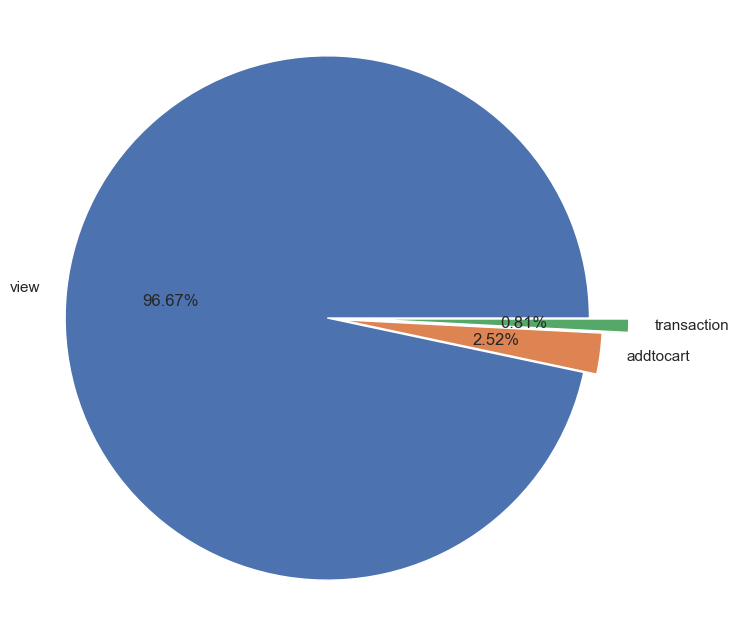

In [5]:
data = df_ev.event.value_counts()
labels = data.index
sizes = data.values
explode = (0, 0.05, 0.15)
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    sizes, labels=labels, explode=explode, autopct="%1.2f%%", shadow=False, startangle=0
)

ax.axis("equal")
plt.show()

In [6]:
print("Quantidade de valor nulos por coluna")
print(df_ev.isnull().sum())
print()

print("Porcentagem de nulos")
print((df_ev.isnull().sum() / len(df_ev) * 100).round(2))
print()

print("Total duplicadas")
print(df_ev.duplicated().sum())
print()

Quantidade de valor nulos por coluna
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Porcentagem de nulos
timestamp         0.00
visitorid         0.00
event             0.00
itemid            0.00
transactionid    99.19
dtype: float64

Total duplicadas
460



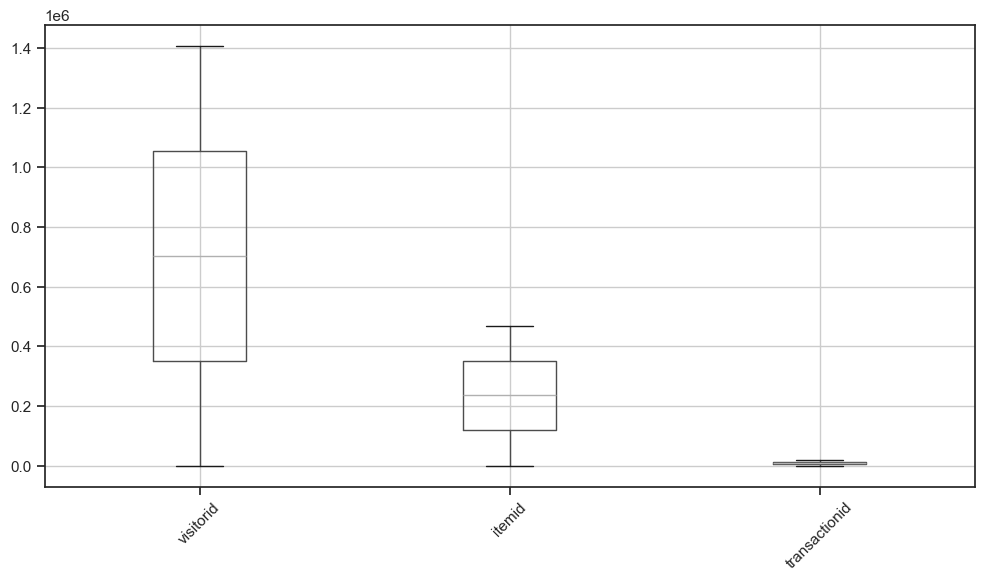

visitorid: 0 outliers
itemid: 0 outliers
transactionid: 0 outliers


In [7]:
# Visualização rápida
df_ev[colunas_numericas].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

# Método IQR
for col in colunas_numericas:
    Q1 = df_ev[col].quantile(0.25)
    Q3 = df_ev[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_ev[col] < Q1 - 1.5 * IQR) | (df_ev[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers")

In [8]:
print("Valores únicos e frequência")
# Ver valores únicos e frequência
for col in colunas_categoricas:
    print(f"\n{col}: {df_ev[col].nunique()} valores únicos")
    print(df_ev[col].value_counts().head(10))

Valores únicos e frequência

event: 3 valores únicos
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


## Quantidades
- Views em grandes quantidades 2664312
- Add to cart em segundo lugar 69332
- Transações em terceiro 22457

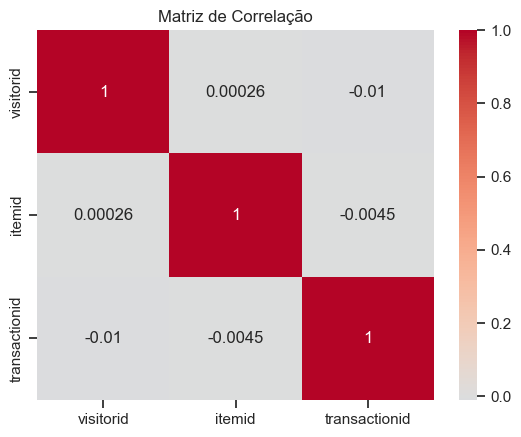

In [9]:
# Matriz de correlação
correlacao = df_ev[colunas_numericas].corr()


# Visualizar
sns.heatmap(correlacao, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()

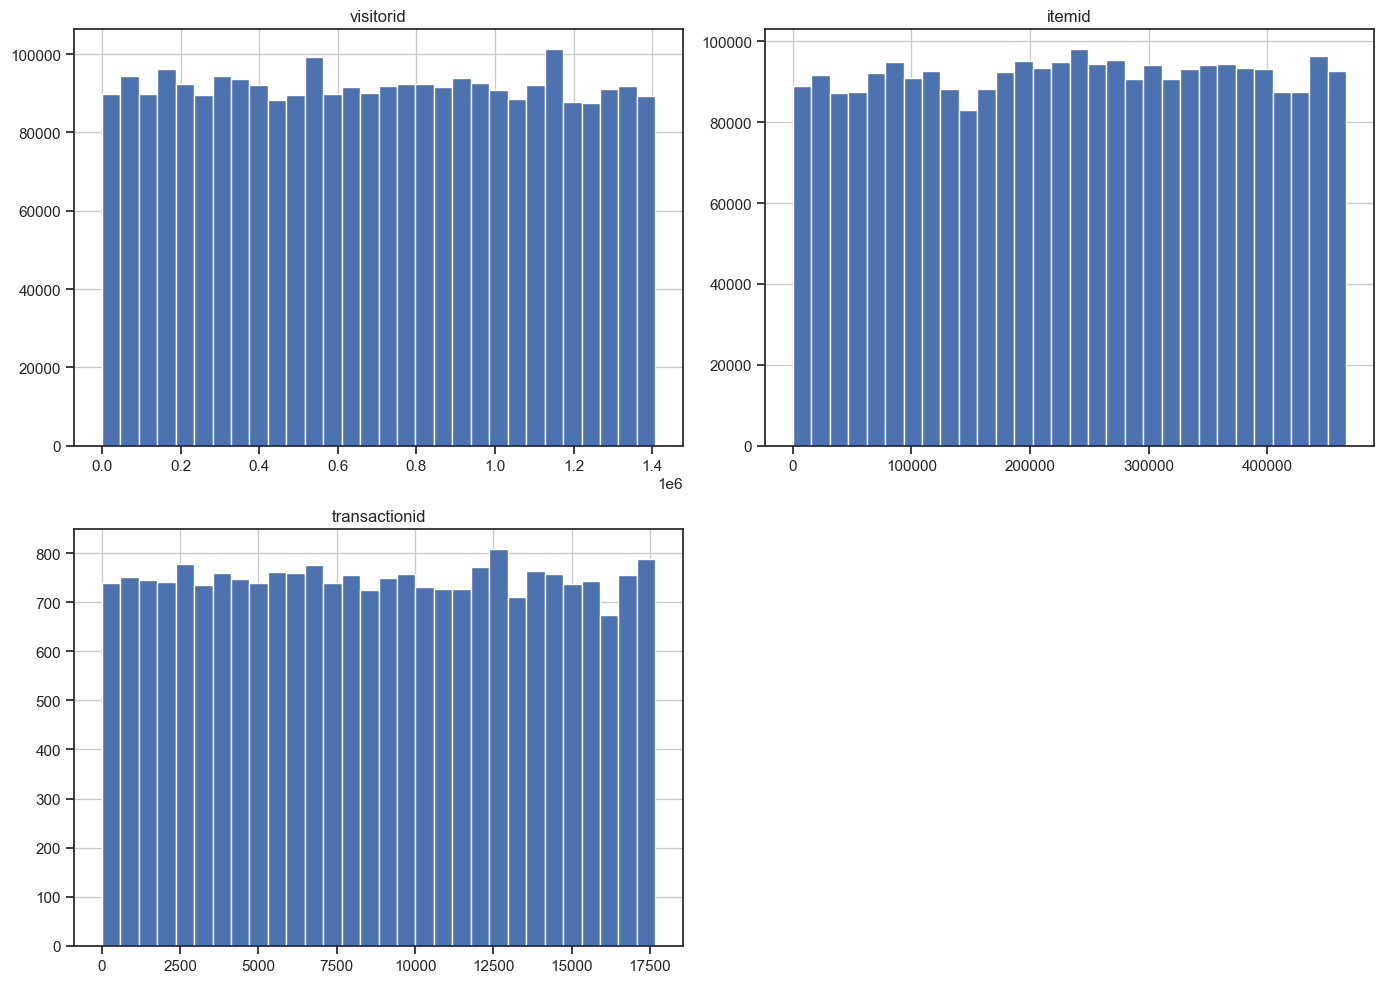

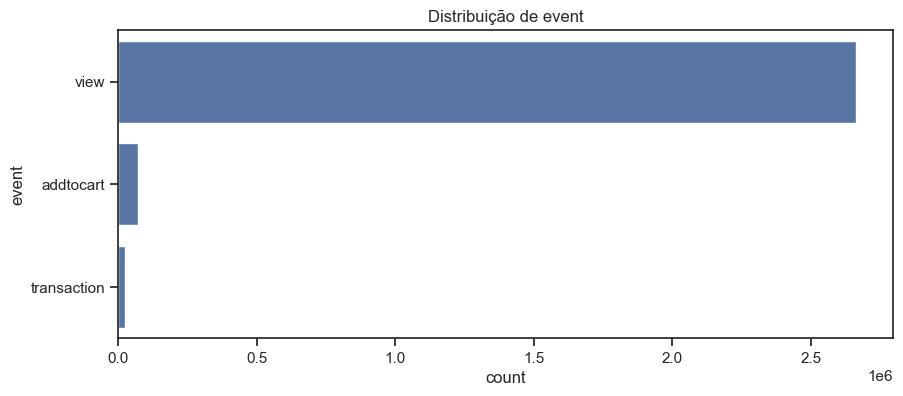

In [10]:
# Histograma para todas as numéricas
df_ev[colunas_numericas].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

# Countplot para categóricas principais
for col in colunas_categoricas[:5]:  # top 5
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df_ev, order=df_ev[col].value_counts().index[:10])
    plt.title(f"Distribuição de {col}")
    plt.show()

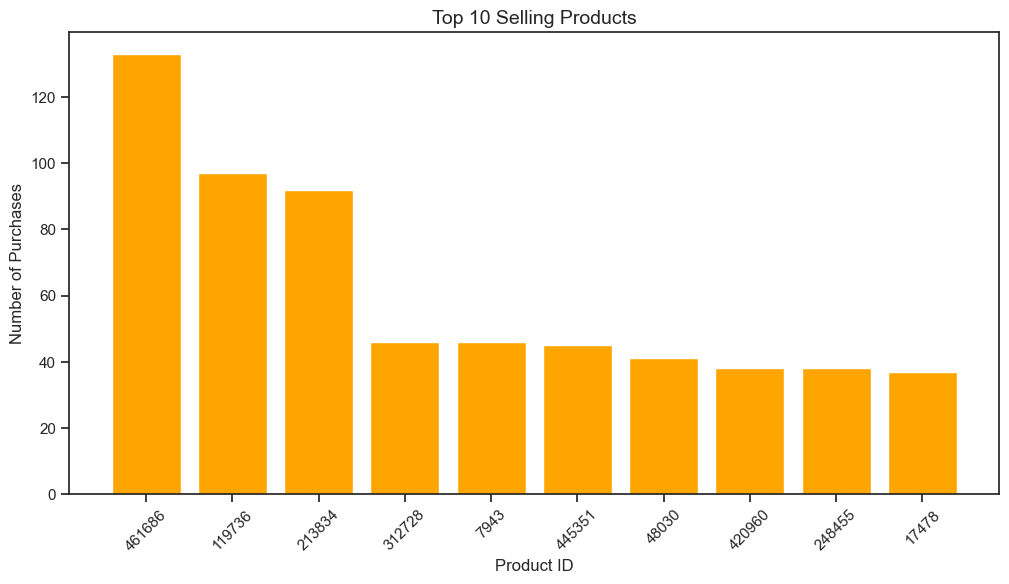

In [11]:
top_products = (
    df_ev[df_ev["event"] == "transaction"]
    .groupby("itemid")
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)

top_products_df = top_products.head(10)
plt.figure(figsize=(12, 6))
plt.bar(
    top_products_df["itemid"].astype(str),
    top_products_df["purchase_count"],
    color="orange",
)
plt.title("Top 10 Selling Products", fontsize=14)
plt.xlabel("Product ID", fontsize=12)
plt.ylabel("Number of Purchases", fontsize=12)
plt.xticks(rotation=45)
plt.show()

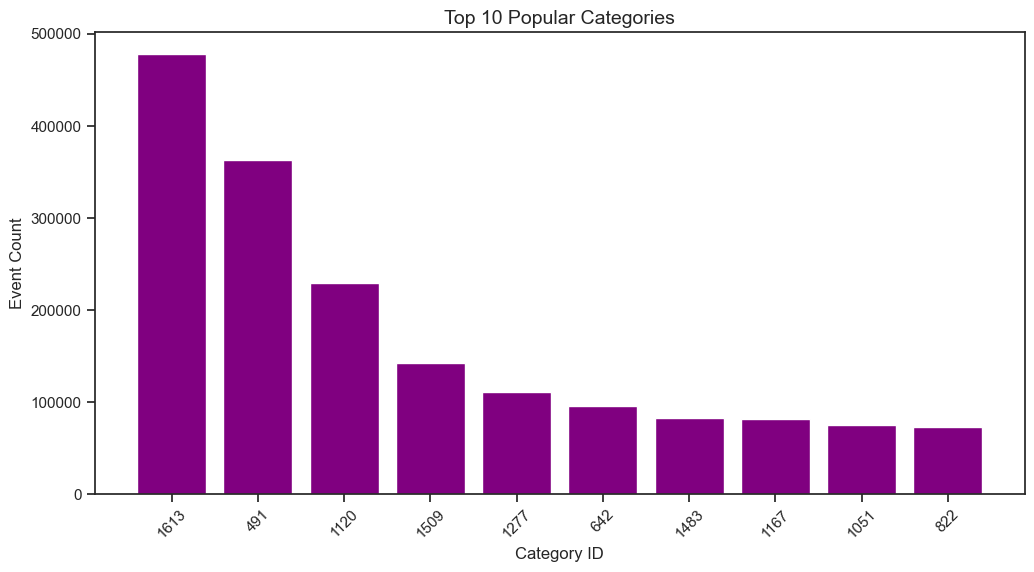

In [12]:
# 1. Fazer o join (inner join) entre events e item_properties
events_with_properties = df_ev.merge(
    df_ip[df_ip["property"] == "categoryid"],
    on="itemid",
    how="inner",
)

# 2. Agrupar por categoria e contar eventos
category_popularity = (
    events_with_properties.groupby("value")  # value = categoryid
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

# 3. Plotar os top 10
category_popularity_df = category_popularity.head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    category_popularity_df["value"].astype(str),
    category_popularity_df["event_count"],
    color="purple",
)
plt.title("Top 10 Popular Categories", fontsize=14)
plt.xlabel("Category ID", fontsize=12)
plt.ylabel("Event Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

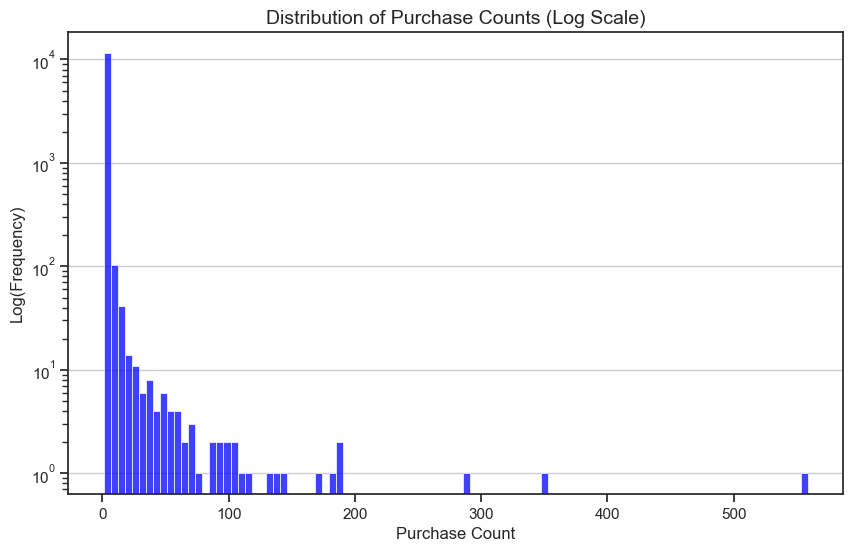

In [13]:
# Top clientes por número de transações
top_customers = (
    df_ev[df_ev["event"] == "transaction"]
    .groupby("visitorid")
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)

# Plot Histogram with Logarithmic y-axis
plt.figure(figsize=(10, 6))
sns.histplot(top_customers["purchase_count"], bins=100, kde=False, color="blue")
plt.yscale("log")
plt.title("Distribution of Purchase Counts (Log Scale)", fontsize=14)
plt.xlabel("Purchase Count", fontsize=12)
plt.ylabel("Log(Frequency)", fontsize=12)
plt.grid(axis="y")
plt.show()

/var/folders/js/zhbxq7yx3h1f43_xdzb1nmb40000gn/T/ipykernel_71695/1633729506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


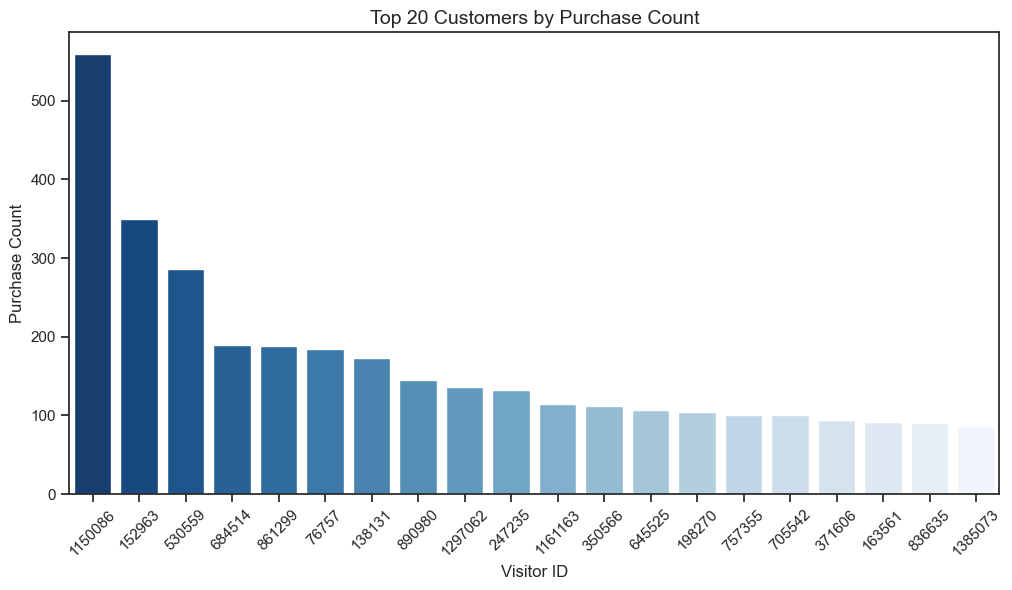

In [14]:
# Sort by purchase_count
top_n = top_customers.nlargest(20, "purchase_count")

# Plot Pareto Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_n["visitorid"].astype(str), y=top_n["purchase_count"], palette="Blues_r"
)
plt.title("Top 20 Customers by Purchase Count", fontsize=14)
plt.xlabel("Visitor ID", fontsize=12)
plt.ylabel("Purchase Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [15]:
# Verificar se o timestamp foi convertido corretamente
print("Tipo do timestamp:", df_ev["timestamp"].dtype)
print("\nAmostra de timestamps:")
print(df_ev["timestamp"].head())

# Verificar o range de datas
print("\nPeríodo dos dados:")
print(f"Min: {df_ev['timestamp'].min()}")
print(f"Max: {df_ev['timestamp'].max()}")

# Verificar quais dias da semana realmente existem
df_temp = df_ev[df_ev["event"] == "transaction"].copy()
df_temp["weekday"] = df_temp["timestamp"].dt.day_name()
print("\nDias da semana encontrados:")
print(df_temp["weekday"].value_counts())

Tipo do timestamp: datetime64[ms]

Amostra de timestamps:
0   2015-06-02 05:02:12.117
1   2015-06-02 05:50:14.164
2   2015-06-02 05:13:19.827
3   2015-06-02 05:12:35.914
4   2015-06-02 05:02:17.106
Name: timestamp, dtype: datetime64[ms]

Período dos dados:
Min: 2015-05-03 03:00:04.384000
Max: 2015-09-18 02:59:47.788000

Dias da semana encontrados:
weekday
Wednesday    4151
Tuesday      3973
Monday       3848
Thursday     3750
Friday       2929
Sunday       1995
Saturday     1811
Name: count, dtype: int64


In [16]:
# Mapeamento dos dias da semana (locale-independent)
dias_semana = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

# Análise por dia da semana (versão robusta)
purchase_weekday = (
    df_ev[df_ev["event"] == "transaction"]
    .assign(weekday=lambda df: df["timestamp"].dt.weekday)  # Número (0=seg, 6=dom)
    .groupby("weekday")
    .size()
    .reindex(range(7), fill_value=0)  # Garante todos os 7 dias
    .reset_index(name="purchase_count")
)

# Mapear números para nomes
purchase_weekday["weekday"] = purchase_weekday["weekday"].map(dias_semana)

print(purchase_weekday)

     weekday  purchase_count
0     Monday            3848
1    Tuesday            3973
2  Wednesday            4151
3   Thursday            3750
4     Friday            2929
5   Saturday            1811
6     Sunday            1995


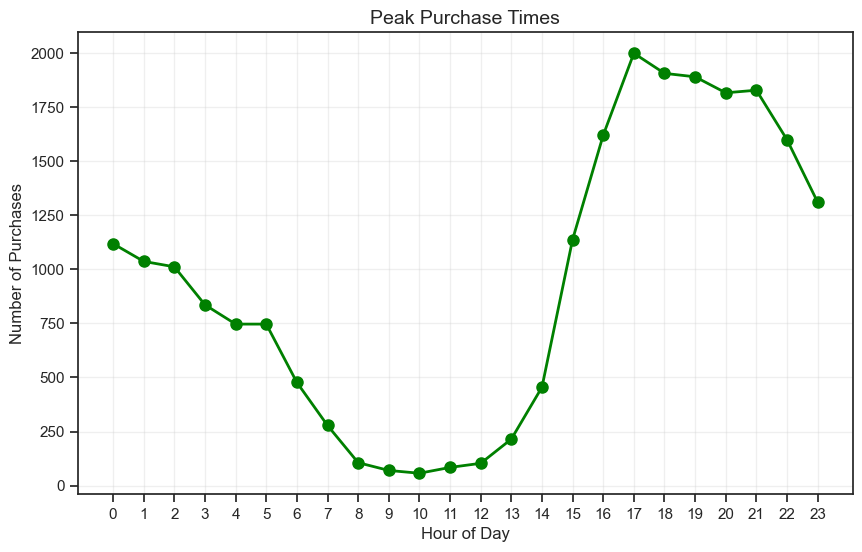

In [17]:
# 2. Criar purchase_times
purchase_times = (
    df_ev[df_ev["event"] == "transaction"]
    .assign(hour=lambda df: df["timestamp"].dt.hour)
    .groupby("hour")
    .size()
    .reset_index(name="purchase_count")
    .sort_values("hour")
)

# 3. Visualizar
plt.figure(figsize=(10, 6))
plt.plot(
    purchase_times["hour"],
    purchase_times["purchase_count"],
    marker="o",
    color="green",
    linewidth=2,
    markersize=8,
)
plt.title("Peak Purchase Times", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Purchases", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()